# Pittsburgh Condemned & Dead-End Property — Point Density Heatmap

Visualizes the spatial distribution of condemned/dead-end properties in Pittsburgh using:
- **Base map**: Pittsburgh neighborhood boundaries from WPRDC (official city GeoJSON)
- **Density estimation**: SciPy Gaussian KDE on property lat/lon coordinates
- **Output**: Static PNG saved to `../output/heatmap.png`

In [1]:
import sys, subprocess

# Install into THIS kernel's Python (handles mismatched environments)
subprocess.check_call([sys.executable, "-m", "pip", "install",
                       "geopandas==0.14.4", "matplotlib==3.9.0",
                       "scipy==1.13.0", "numpy==1.26.4", "-q"])

import os
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

print("Kernel:", sys.executable)
print("All imports OK")

Kernel: /Volumes/D/Dev/python_envs/anaconda3/envs/SatelliteData/bin/python
All imports OK


In [2]:
# ── Load property data ──────────────────────────────────────────────────────
df = pd.read_csv("../data/cleaned_data.csv")
df = df.dropna(subset=["latitude", "longitude"])
print(f"Valid coordinate records: {len(df)}")
df[["latitude", "longitude"]].describe()

Valid coordinate records: 2584


,latitude,longitude
count,2584.000000,2584.000000
mean,40.443081,-79.972518
std,0.025638,0.050074
min,40.365016,-80.084238
25%,40.418258,-80.009093
50%,40.451855,-79.981315
75%,40.462983,-79.937054
max,40.491728,-79.872145


In [3]:
# ── Load Pittsburgh neighborhood boundaries (WPRDC official GeoJSON) ────────
# Primary: ArcGIS Open Data (Pittsburgh City Planning)
NEIGHBORHOODS_URL = (
    "https://opendata.arcgis.com/datasets/"
    "dbd133a206cc4a3aa915cb28baa60fd4_0.geojson"
)

try:
    pgh = gpd.read_file(NEIGHBORHOODS_URL)
    print(f"Loaded {len(pgh)} neighborhoods from ArcGIS Open Data")
except Exception as e:
    print(f"Primary URL failed ({e}), trying local fallback...")
    pgh = gpd.read_file("../data/pittsburgh_neighborhoods.geojson")
    print(f"Loaded {len(pgh)} neighborhoods from local file")

pgh = pgh.to_crs(epsg=4326)  # ensure WGS84
print(f"CRS: {pgh.crs}")
print(f"Bounds: {pgh.total_bounds}")

Loaded 90 neighborhoods from ArcGIS Open Data
CRS: EPSG:4326
Bounds: [-80.09533135  40.36152196 -79.86584628  40.50104498]


In [4]:
# ── Compute Gaussian KDE on a 500x500 grid ───────────────────────────────
lon = df["longitude"].values
lat = df["latitude"].values

lon_min, lat_min, lon_max, lat_max = pgh.total_bounds

margin = 0.01
lon_min -= margin; lon_max += margin
lat_min -= margin; lat_max += margin

grid_size = 500
xx, yy = np.mgrid[lon_min:lon_max:complex(grid_size),
                  lat_min:lat_max:complex(grid_size)]

positions = np.vstack([xx.ravel(), yy.ravel()])
values    = np.vstack([lon, lat])

# Increased bandwidth: smoother, larger hotspot blobs
kernel = gaussian_kde(values, bw_method=0.07)
zz = np.reshape(kernel(positions), xx.shape)

print(f"KDE grid: {zz.shape}, range: [{zz.min():.4f}, {zz.max():.4f}]")

KDE grid: (500, 500), range: [0.0000, 715.3494]


Saved to ../output/heatmap.png


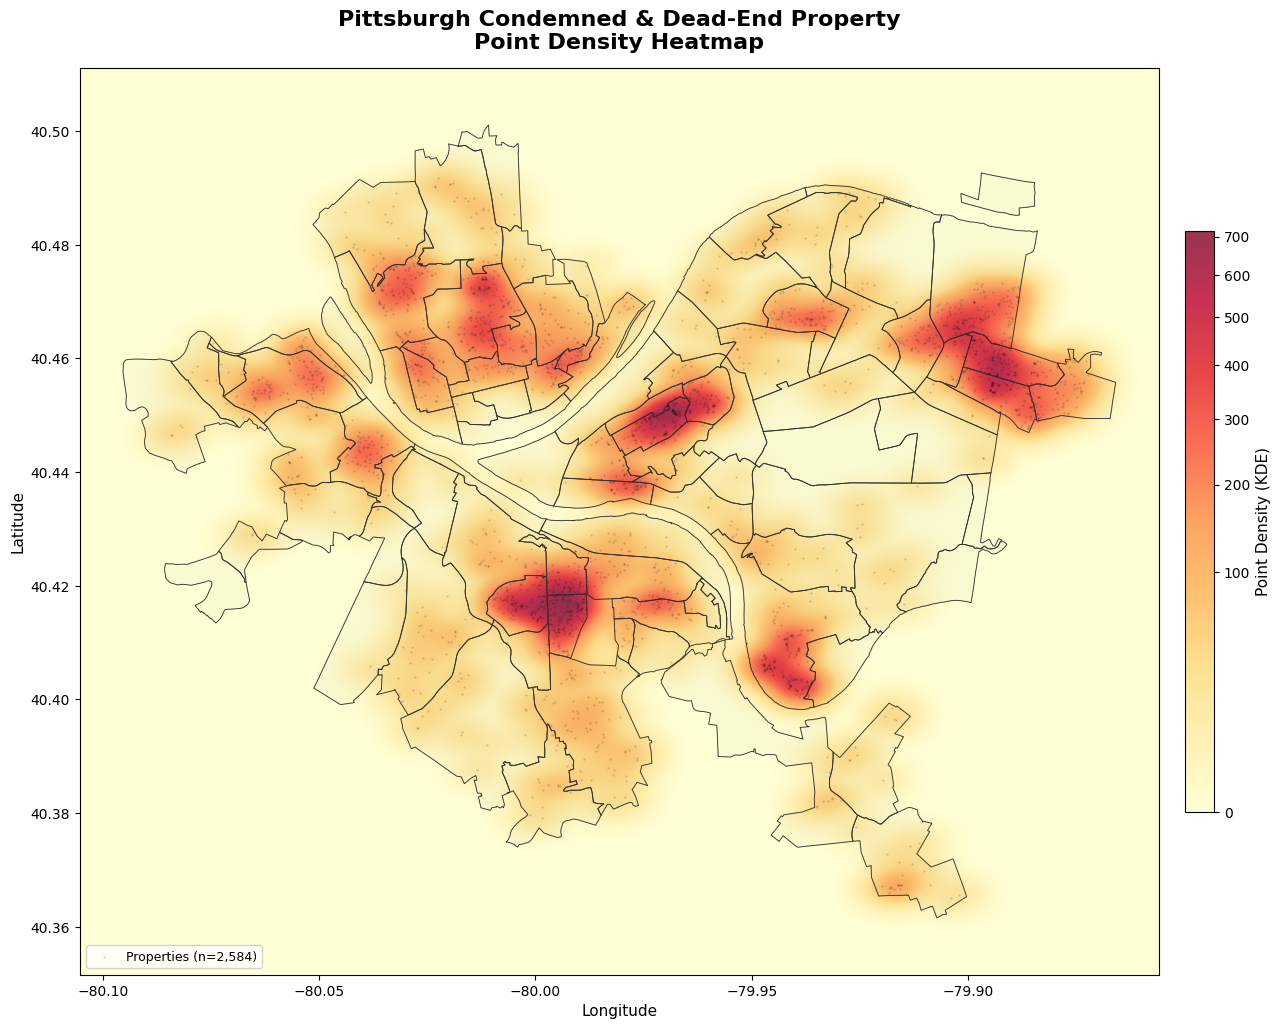

In [5]:
# ── Plot ─────────────────────────────────────────────────────────────────
from matplotlib.colors import PowerNorm

fig, ax = plt.subplots(figsize=(14, 11))

# 1. Base map
pgh.plot(ax=ax, color="#e8e8e8", edgecolor="#555555", linewidth=0.8, zorder=1)

# 2. KDE heatmap — PowerNorm(gamma<1) stretches low-density colours,
#    compresses high-density so the full range reads clearly
norm = PowerNorm(gamma=0.45, vmin=zz.min(), vmax=zz.max())
img = ax.imshow(
    zz.T,
    origin="lower",
    extent=[lon_min, lon_max, lat_min, lat_max],
    cmap="YlOrRd",
    norm=norm,
    alpha=0.80,
    aspect="auto",
    zorder=2,
)

# 3. Neighborhood outlines on top
pgh.plot(ax=ax, color="none", edgecolor="#333333", linewidth=0.6, zorder=3)

# 4. Scatter — smaller, more transparent
ax.scatter(lon, lat, s=2.5, c="#111111", alpha=0.18, linewidths=0, zorder=4,
           label=f"Properties (n={len(df):,})")

# 5. Colorbar with readable ticks
cbar = plt.colorbar(img, ax=ax, shrink=0.55, pad=0.02)
cbar.set_label("Point Density (KDE)", fontsize=11)

# 6. Labels & title
ax.set_title(
    "Pittsburgh Condemned & Dead-End Property\nPoint Density Heatmap",
    fontsize=16, fontweight="bold", pad=14
)
ax.set_xlabel("Longitude", fontsize=11)
ax.set_ylabel("Latitude",  fontsize=11)
ax.legend(loc="lower left", fontsize=9, framealpha=0.85)
ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)

plt.tight_layout()

os.makedirs("../output", exist_ok=True)
out_path = "../output/heatmap.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved to {out_path}")
plt.show()